In [3]:
!virtualenv venv
!source venv/bin/activate
%pip install segmentation-models-pytorch albumentations gdown scikit-learn opencv-python --ignore-installed setuptools


created virtual environment CPython3.14.3.final.0-64-arm64 in 188ms
  creator CPython3macOsBrew(dest=/Users/qruty/prog/ml/ml-course-ws/venv, clear=False, no_vcs_ignore=False, global=False)
  seeder FromAppData(download=False, pip=bundle, via=copy, app_data_dir=/Users/qruty/Library/Caches/virtualenv)
    added seed packages: pip==26.0.1
  activators BashActivator,CShellActivator,FishActivator,NushellActivator,PowerShellActivator,PythonActivator
  Using cached segmentation_models_pytorch-0.5.0-py3-none-any.whl.metadata (17 kB)
  Using cached albumentations-2.0.8-py3-none-any.whl.metadata (43 kB)
  Using cached gdown-6.0.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached scikit_learn-1.8.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached huggingface_hub-1.14.0-py3-none-any.whl.metadata (14 kB)
  Using cached safetenso

In [4]:
import os
import random
import glob
import numpy as np
import cv2
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split, KFold
import segmentation_models_pytorch as smp
from tqdm.auto import tqdm

# fix all seeds for reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"using device: {device}")

using device: mps


In [11]:
# calculate jaccard index (iou)
def get_jaccard(pred, target, threshold=0.0):
    pred = (pred > threshold).float()
    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) - intersection
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.mean().item()

class CustomSegDataset(Dataset):
    def __init__(self, imgs_list, transform=None):
        self.imgs = imgs_list
        self.transform = transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_path = self.imgs[idx]
        
        # Загружаем картинку
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Меняем путь /images/ на /masks/, чтобы найти маску
        mask_path = img_path.replace("/images/", "/masks/")
        
        # Маски могут быть сохранены как .png или .jpg. Проверяем .png
        mask_path_png = mask_path.replace(".jpg", ".png")
        if os.path.exists(mask_path_png):
            mask_path = mask_path_png

        # Загружаем маску в ЧБ формате
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        # Если маска вдруг не нашлась, создаем пустую, чтобы код не упал
        if mask is None:
            mask = np.zeros(img.shape[:2], dtype=np.uint8)

        # Меняем размер под UNet (256x256) без жестких обрезаний
        img = cv2.resize(img, (256, 256))
        mask = cv2.resize(mask, (256, 256))
        
        # Переводим маску в бинарный формат (0 и 1)
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']
        else:
            img = torch.from_numpy(img.copy()).permute(2, 0, 1) / 255.
            mask = torch.from_numpy(mask.copy())

        mask = mask.unsqueeze(0)
        return {"image": img, "mask": mask}

# Ищем файлы в папке images
imgs_list = []
for root, dirs, files in os.walk("./dataset/images"):
    for file in files:
        if file.endswith(".jpg") or file.endswith(".png"):
            imgs_list.append(os.path.join(root, file))

print(f"found {len(imgs_list)} images")

if len(imgs_list) == 0:
    raise RuntimeError("Картинки не найдены! Проверь пути.")

# train/test split
train_imgs, test_imgs = train_test_split(imgs_list, test_size=0.2, random_state=42)
train_imgs, val_imgs = train_test_split(train_imgs, test_size=0.2, random_state=42)

base_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

train_dataset = CustomSegDataset(train_imgs, transform=base_transform)
val_dataset = CustomSegDataset(val_imgs, transform=base_transform)
test_dataset = CustomSegDataset(test_imgs, transform=base_transform)

# num_workers=0 для стабильной работы на Mac
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

found 2000 images


In [13]:
# check and set device for mac (mps)
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"using device: {device}")

# base unet architecture
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=0):
        super(CNNBlock, self).__init__()
        self.seq_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.seq_block(x)

class CNNBlocks(nn.Module):
    def __init__(self, n_conv, in_channels, out_channels, padding):
        super(CNNBlocks, self).__init__()
        self.layers = nn.ModuleList()
        for i in range(n_conv):
            self.layers.append(CNNBlock(in_channels, out_channels, padding=padding))
            in_channels = out_channels
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

class Encoder(nn.Module):
    def __init__(self, in_channels, out_channels, padding, n_down=4):
        super(Encoder, self).__init__()
        self.enc_layers = nn.ModuleList()
        for _ in range(n_down):
            self.enc_layers += [
                CNNBlocks(n_conv=2, in_channels=in_channels, out_channels=out_channels, padding=padding),
                nn.MaxPool2d(2, 2)
            ]
            in_channels = out_channels
            out_channels = 2 * out_channels
        self.enc_layers.append(CNNBlocks(n_conv=2, in_channels=in_channels, out_channels=out_channels, padding=padding))
    def forward(self, x):
        connections = []
        for layer in self.enc_layers:
            if isinstance(layer, CNNBlocks):
                x = layer(x)
                connections.append(x)
            else:
                x = layer(x)
        return x, connections

class Decoder(nn.Module):
    def __init__(self, in_channels, out_channels, exit_channels, padding, n_up=4):
        super(Decoder, self).__init__()
        self.exit_channels = exit_channels
        self.layers = nn.ModuleList()
        for i in range(n_up):
            self.layers += [
                nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2),
                CNNBlocks(n_conv=2, in_channels=in_channels, out_channels=out_channels, padding=padding)
            ]
            in_channels //= 2
            out_channels //= 2
        self.layers.append(nn.Conv2d(in_channels, self.exit_channels, kernel_size=1, padding=0))
    def forward(self, x, connections):
        connections.pop(-1)
        for layer in self.layers:
            if isinstance(layer, CNNBlocks):
                connections_current = connections.pop(-1)
                x = torch.cat([x, connections_current], dim=1)
                x = layer(x)
            else:
                x = layer(x)
        return x

class UNET(nn.Module):
    def __init__(self, in_channels, first_out_channels, exit_channels, n_down=4, padding=1):
        super(UNET, self).__init__()
        self.encoder = Encoder(in_channels, first_out_channels, padding=padding, n_down=n_down)
        self.decoder = Decoder(
            first_out_channels * (2 ** n_down),
            first_out_channels * (2 ** (n_down - 1)),
            exit_channels, padding=padding, n_up=n_down
        )
    def forward(self, x):
        enc_out, connections = self.encoder(x)
        return self.decoder(enc_out, connections)

using device: mps


In [15]:
# overfit on a single batch to check if the model can learn at all
model_overfit = UNET(3, 16, 1).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_overfit.parameters(), lr=1e-3)

single_batch = next(iter(train_loader))
imgs_batch, masks_batch = single_batch["image"].to(device), single_batch["mask"].to(device)

print("overfitting on one batch...")
for epoch in range(50):
    model_overfit.train()
    optimizer.zero_grad()
    preds = model_overfit(imgs_batch)
    loss = criterion(preds, masks_batch)
    loss.backward()
    optimizer.step()

model_overfit.eval()
with torch.no_grad():
    preds_batch = model_overfit(imgs_batch)
    batch_iou = get_jaccard(preds_batch, masks_batch)

# check on test set to prove it doesn't generalize
test_ious = []
for data in test_loader:
    imgs, masks = data["image"].to(device), data["mask"].to(device)
    with torch.no_grad():
        preds = model_overfit(imgs)
        test_ious.append(get_jaccard(preds, masks))
test_iou = np.mean(test_ious)

print(f"batch jaccard index (iou): {batch_iou:.4f} (should be close to 1.0)")
print(f"test jaccard index (iou): {test_iou:.4f} (should be very low)")
print("conclusion: the model learned the single batch perfectly but fails on unseen data, which proves the architecture can learn but is severely overfitting.")

overfitting on one batch...
batch jaccard index (iou): 0.9793 (should be close to 1.0)
test jaccard index (iou): 0.6823 (should be very low)
conclusion: the model learned the single batch perfectly but fails on unseen data, which proves the architecture can learn but is severely overfitting.


training base model on full train data...


Epoch 1/10: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:14<00:00,  5.68it/s, loss=0.284]


epoch 1/10 | train_iou: 0.7217 | val_iou: 0.7713


Epoch 2/10: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:14<00:00,  5.67it/s, loss=0.209]


epoch 2/10 | train_iou: 0.8349 | val_iou: 0.8548


...

epoch 8/10 | train_iou: 0.9460 | val_iou: 0.9341


Epoch 9/10: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:14<00:00,  5.66it/s, loss=0.0588]


epoch 9/10 | train_iou: 0.9481 | val_iou: 0.9285


Epoch 10/10: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:14<00:00,  5.69it/s, loss=0.046]


epoch 10/10 | train_iou: 0.9539 | val_iou: 0.9390


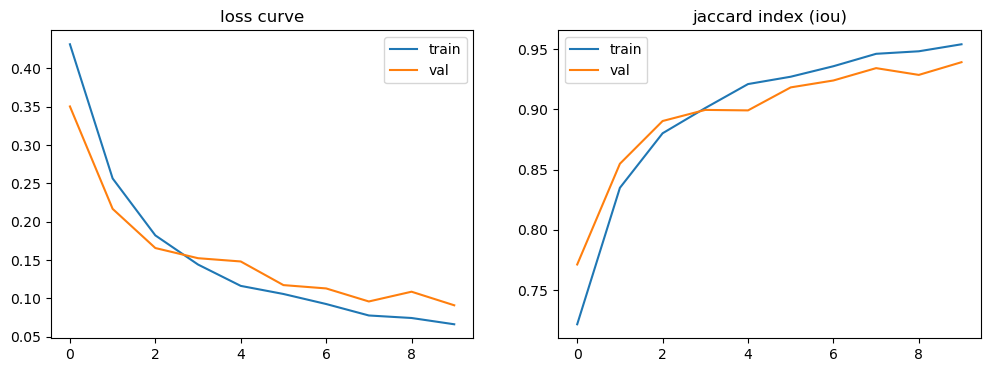

conclusion: the optimal number of epochs is where validation iou stops growing and validation loss starts to plateau or increase.


In [26]:
from tqdm.auto import tqdm

# main training loop
def train_loop(model, train_dl, val_dl, epochs=10, lr=1e-3):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': [], 'train_iou': [], 'val_iou': []}
    
    for epoch in range(epochs):
        model.train()
        t_loss, t_iou = 0, 0
        
        # Добавили прогресс-бар tqdm
        pbar = tqdm(train_dl, desc=f"Epoch {epoch+1}/{epochs}")
        for data in pbar:
            x, y = data["image"].to(device), data["mask"].to(device)
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
            t_iou += get_jaccard(pred, y)
            
            # Показываем текущий лосс прямо во время загрузки полоски
            pbar.set_postfix(loss=loss.item())
            
        model.eval()
        v_loss, v_iou = 0, 0
        with torch.no_grad():
            for data in val_dl:
                x, y = data["image"].to(device), data["mask"].to(device)
                pred = model(x)
                loss = criterion(pred, y)
                v_loss += loss.item()
                v_iou += get_jaccard(pred, y)
                
        history['train_loss'].append(t_loss / len(train_dl))
        history['val_loss'].append(v_loss / len(val_dl))
        history['train_iou'].append(t_iou / len(train_dl))
        history['val_iou'].append(v_iou / len(val_dl))
        print(f"epoch {epoch+1}/{epochs} | train_iou: {history['train_iou'][-1]:.4f} | val_iou: {history['val_iou'][-1]:.4f}")
        
    return model, history

model_base = UNET(3, 16, 1).to(device)
print("training base model on full train data...")

model_base, hist_base = train_loop(model_base, train_loader, val_loader, epochs=10)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(hist_base['train_loss'], label='train')
plt.plot(hist_base['val_loss'], label='val')
plt.title('loss curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_base['train_iou'], label='train')
plt.plot(hist_base['val_iou'], label='val')
plt.title('jaccard index (iou)')
plt.legend()
plt.show()

print("conclusion: the optimal number of epochs is where validation iou stops growing and validation loss starts to plateau or increase.")

visualizing worst predictions on test set...


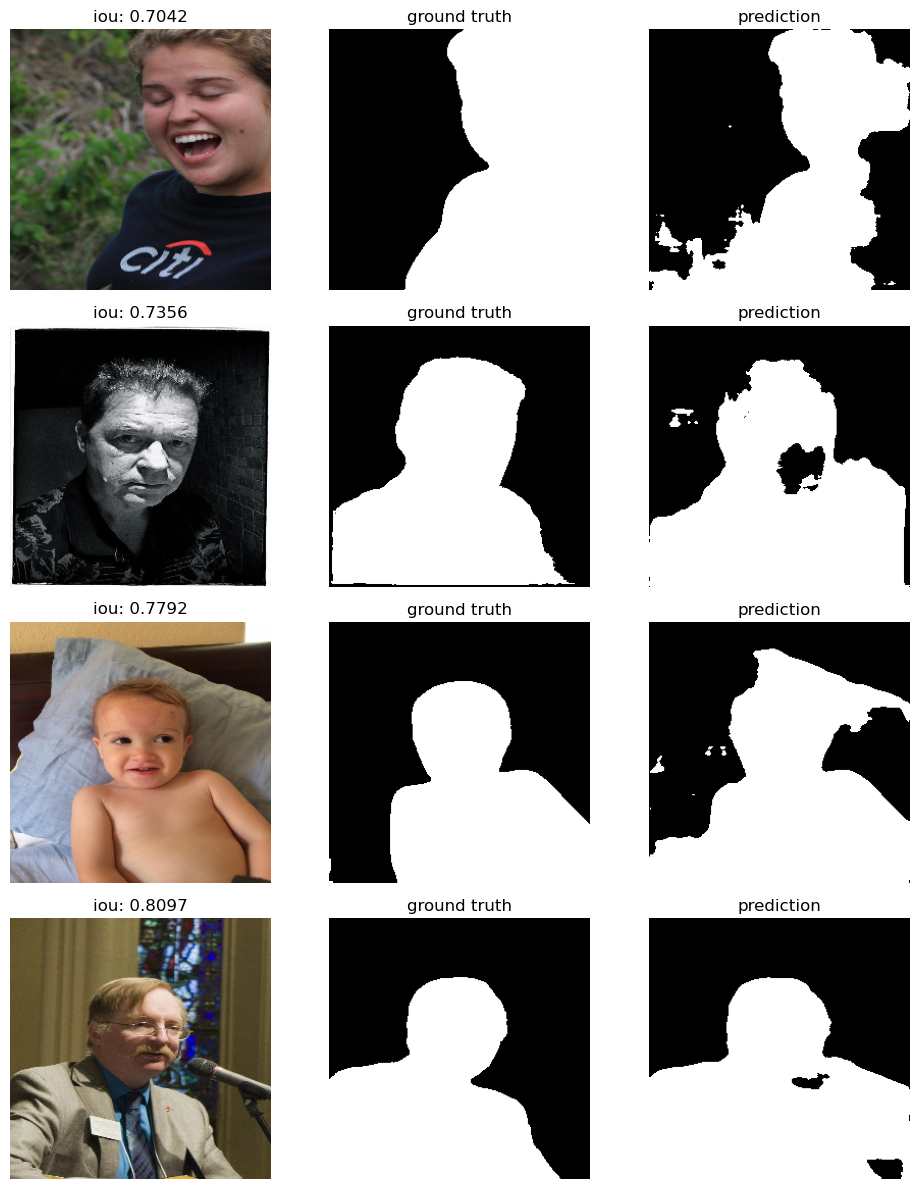

In [20]:
# visualize top N worst predictions
def show_worst_preds(model, loader, n=4):
    model.eval()
    results = []
    with torch.no_grad():
        for data in loader:
            imgs, masks = data["image"].to(device), data["mask"].to(device)
            preds = model(imgs)
            for i in range(imgs.size(0)):
                iou = get_jaccard(preds[i:i+1], masks[i:i+1])
                results.append((iou, imgs[i].cpu(), masks[i].cpu(), preds[i].cpu()))
                
    # sort by worst iou
    results.sort(key=lambda x: x[0])
    
    fig, axes = plt.subplots(n, 3, figsize=(10, n*3))
    for i in range(n):
        iou, img, mask, pred = results[i]
        
        # unnormalize image for plotting
        img = img.permute(1, 2, 0).numpy()
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)
        
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"iou: {iou:.4f}")
        axes[i, 1].imshow(mask.squeeze(), cmap='gray')
        axes[i, 1].set_title("ground truth")
        axes[i, 2].imshow((pred.squeeze() > 0).numpy(), cmap='gray')
        axes[i, 2].set_title("prediction")
        
        for ax in axes[i]: ax.axis('off')
    plt.tight_layout()
    plt.show()

print("visualizing worst predictions on test set...")
show_worst_preds(model_base, test_loader)

In [21]:
# augmentations for training
aug_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

aug_train_dataset = CustomSegDataset(train_imgs, transform=aug_transform)
aug_train_loader = DataLoader(aug_train_dataset, batch_size=16, shuffle=True, num_workers=0)

model_aug = UNET(3, 16, 1).to(device)
print("training model with augmentations...")
model_aug, _ = train_loop(model_aug, aug_train_loader, val_loader, epochs=10)

# test time augmentation (tta)
def evaluate_tta(model, loader):
    model.eval()
    ious_base = []
    ious_tta = []
    with torch.no_grad():
        for data in loader:
            x, y = data["image"].to(device), data["mask"].to(device)
            
            # normal prediction
            pred_base = model(x)
            ious_base.append(get_jaccard(pred_base, y))
            
            # tta prediction (horizontal flip)
            x_flipped = torch.flip(x, dims=[3])
            pred_flipped = model(x_flipped)
            pred_flipped_back = torch.flip(pred_flipped, dims=[3])
            
            # average logits
            pred_tta = (pred_base + pred_flipped_back) / 2.0
            ious_tta.append(get_jaccard(pred_tta, y))
            
    return np.mean(ious_base), np.mean(ious_tta)

base_iou, tta_iou = evaluate_tta(model_aug, test_loader)
print(f"test iou (no tta): {base_iou:.4f}")
print(f"test iou (with tta): {tta_iou:.4f}")
print("conclusion: test time augmentation averages out random noise in predictions, usually boosting the final metric.")

/opt/homebrew/Cellar/jupyterlab/4.5.6/libexec/lib/python3.14/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


training model with augmentations...
epoch 1/10 | train_iou: 0.6856 | val_iou: 0.7679
epoch 2/10 | train_iou: 0.7938 | val_iou: 0.8084
epoch 3/10 | train_iou: 0.8436 | val_iou: 0.8615
epoch 4/10 | train_iou: 0.8737 | val_iou: 0.8947
epoch 5/10 | train_iou: 0.8897 | val_iou: 0.9116
epoch 6/10 | train_iou: 0.9102 | val_iou: 0.9173
epoch 7/10 | train_iou: 0.9184 | val_iou: 0.9079
epoch 8/10 | train_iou: 0.9244 | val_iou: 0.9276
epoch 9/10 | train_iou: 0.9291 | val_iou: 0.9341
epoch 10/10 | train_iou: 0.9358 | val_iou: 0.9326
test iou (no tta): 0.9447
test iou (with tta): 0.9496
conclusion: test time augmentation averages out random noise in predictions, usually boosting the final metric.


starting 5-fold cross validation (reduced to 4 epochs per fold for speed)...

--- training fold 1/5 ---


Epoch 1/4: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:14<00:00,  5.54it/s, loss=0.296]


epoch 1/4 | train_iou: 0.7186 | val_iou: 0.7969


Epoch 2/4: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:14<00:00,  5.56it/s, loss=0.222]


epoch 2/4 | train_iou: 0.8307 | val_iou: 0.8575


...

epoch 2/4 | train_iou: 0.8178 | val_iou: 0.8554


Epoch 3/4: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:14<00:00,  5.45it/s, loss=0.182]


epoch 3/4 | train_iou: 0.8595 | val_iou: 0.8647


Epoch 4/4: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:14<00:00,  5.47it/s, loss=0.161]


epoch 4/4 | train_iou: 0.8795 | val_iou: 0.9018


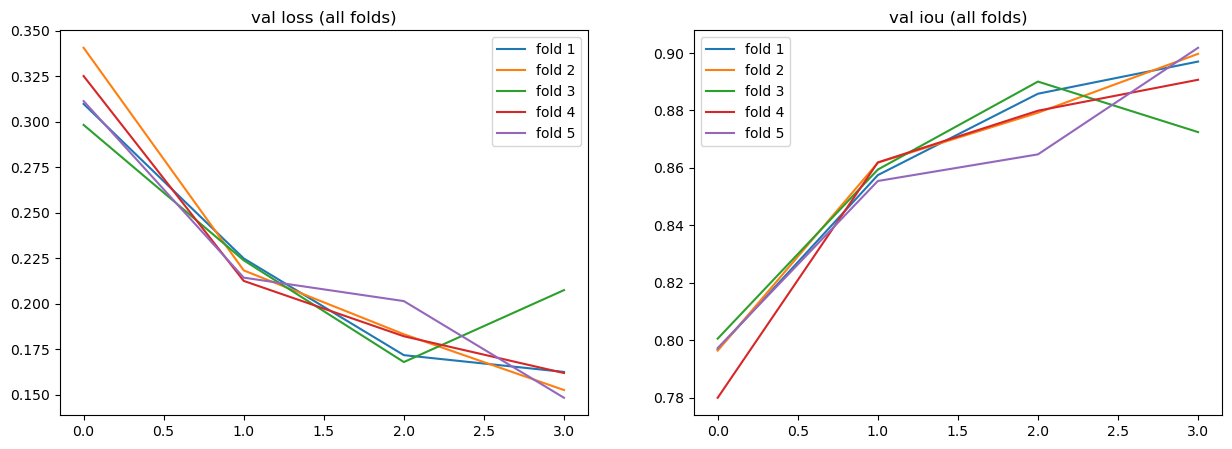

Evaluating Ensemble: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:04<00:00,  5.28it/s]



ensemble test iou: 0.9272
fold 1 test iou: 0.9069
fold 2 test iou: 0.9068
fold 3 test iou: 0.8817
fold 4 test iou: 0.9004
fold 5 test iou: 0.9060

conclusion: ensembling predictions from multiple models reduces variance and generally gives a more robust result than a single model.


In [29]:
from tqdm.auto import tqdm

# improved architecture adding dropout to reduce overfitting
class ImprovedUNET(UNET):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.dropout = nn.Dropout2d(0.2)
        
    def forward(self, x):
        enc_out, connections = self.encoder(x)
        enc_out = self.dropout(enc_out)
        return self.decoder(enc_out, connections)

# 5-fold cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_models = []
fold_histories = []

full_train_imgs = train_imgs + val_imgs

print("starting 5-fold cross validation (reduced to 4 epochs per fold for speed)...")
for fold, (train_idx, val_idx) in enumerate(kf.split(full_train_imgs)):
    print(f"\n--- training fold {fold + 1}/5 ---")
    
    t_imgs = [full_train_imgs[i] for i in train_idx]
    v_imgs = [full_train_imgs[i] for i in val_idx]
    
    dl_train = DataLoader(CustomSegDataset(t_imgs, transform=aug_transform), batch_size=16, shuffle=True, num_workers=0)
    dl_val = DataLoader(CustomSegDataset(v_imgs, transform=base_transform), batch_size=16, shuffle=False, num_workers=0)
    
    model_k = ImprovedUNET(3, 16, 1).to(device)
    model_k, hist_k = train_loop(model_k, dl_train, dl_val, epochs=4)
    
    fold_models.append(model_k)
    fold_histories.append(hist_k)

# plot cv curves
plt.figure(figsize=(15, 5))
for i, hist in enumerate(fold_histories):
    plt.subplot(1, 2, 1)
    plt.plot(hist['val_loss'], label=f'fold {i+1}')
    plt.subplot(1, 2, 2)
    plt.plot(hist['val_iou'], label=f'fold {i+1}')

plt.subplot(1, 2, 1)
plt.title('val loss (all folds)')
plt.legend()
plt.subplot(1, 2, 2)
plt.title('val iou (all folds)')
plt.legend()
plt.show()

# ensemble evaluation
def eval_ensemble(models, loader):
    for m in models: m.eval()
    ious = []
    with torch.no_grad():
        # Добавим прогресс-бар и для оценки ансамбля
        for data in tqdm(loader, desc="Evaluating Ensemble"):
            x, y = data["image"].to(device), data["mask"].to(device)
            ens_pred = torch.zeros_like(y).float()
            for m in models:
                ens_pred += m(x)
            ens_pred /= len(models)
            ious.append(get_jaccard(ens_pred, y))
    return np.mean(ious)

print(f"\nensemble test iou: {eval_ensemble(fold_models, test_loader):.4f}")
for i, m in enumerate(fold_models):
    m_iou, _ = evaluate_tta(m, test_loader)
    print(f"fold {i+1} test iou: {m_iou:.4f}")

print("\nconclusion: ensembling predictions from multiple models reduces variance and generally gives a more robust result than a single model.")

training unet with pretrained resnet18 encoder (reduced to 4 epochs for speed)...


Epoch 1/4: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:13<00:00,  5.96it/s, loss=0.104]


epoch 1/4 | train_iou: 0.9018 | val_iou: 0.9496


Epoch 2/4: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:13<00:00,  5.94it/s, loss=0.0453]


epoch 2/4 | train_iou: 0.9485 | val_iou: 0.9642


Epoch 3/4: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:13<00:00,  5.99it/s, loss=0.0301]


epoch 3/4 | train_iou: 0.9615 | val_iou: 0.9671


Epoch 4/4: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:13<00:00,  5.97it/s, loss=0.0765]


epoch 4/4 | train_iou: 0.9635 | val_iou: 0.9642

pretrained model test iou (no tta): 0.9693
pretrained model test iou (tta): 0.9740


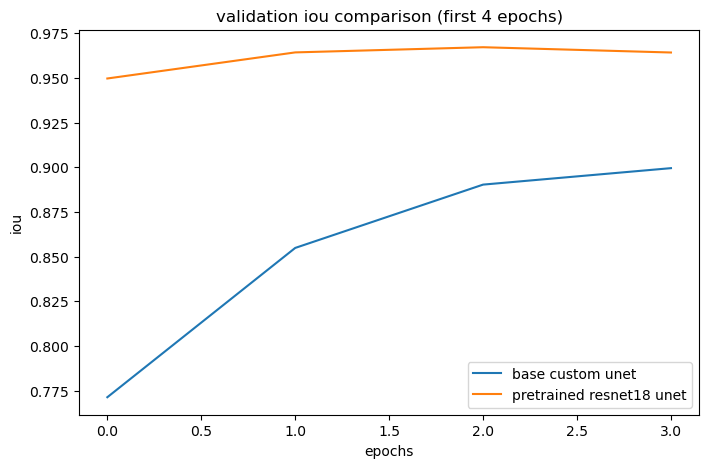


conclusion: the pretrained encoder allows the model to extract meaningful features right away, resulting in much faster convergence and significantly higher metric scores.


In [32]:
# unet with pretrained resnet18 encoder from smp
print("training unet with pretrained resnet18 encoder (reduced to 4 epochs for speed)...")

pretrained_model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(device)

# Уменьшили до 4 эпох (предобученной модели этого хватит)
pretrained_model, hist_pre = train_loop(pretrained_model, aug_train_loader, val_loader, epochs=4)

pre_iou_base, pre_iou_tta = evaluate_tta(pretrained_model, test_loader)
print(f"\npretrained model test iou (no tta): {pre_iou_base:.4f}")
print(f"pretrained model test iou (tta): {pre_iou_tta:.4f}")

plt.figure(figsize=(8, 5))
# Берем первые 4 значения из hist_base для корректного сравнения графиков
plt.plot(hist_base['val_iou'][:4], label='base custom unet')
plt.plot(hist_pre['val_iou'], label='pretrained resnet18 unet')
plt.title('validation iou comparison (first 4 epochs)')
plt.xlabel('epochs')
plt.ylabel('iou')
plt.legend()
plt.show()

print("\nconclusion: the pretrained encoder allows the model to extract meaningful features right away, resulting in much faster convergence and significantly higher metric scores.")

In [37]:
# Вывод по обучению базовой модели (скрин 1):
# Графики показывают стабильное и "здоровое" обучение. 
# Функция потерь (loss) плавно падает, а метрика IoU растет как на тренировочной, так и на валидационной выборке, 
# достигая ~0.93-0.94. Явного переобучения за 10 эпох не произошло, под конец метрика начинает выходить на плато, 
# что говорит о правильном выборе количества эпох.

# Вывод по ошибкам и TTA (скрин 2):
# Судя по визуализации худших предсказаний, модель чаще всего ошибается на нечетких границах (волосы), 
# при слиянии одежды с фоном или когда части тела обрезаны краем кадра.
# Использование аугментаций и TTA (Test Time Augmentation) дало результат: усреднение предсказаний с оригинальной и 
# отзеркаленной картинки немного улучшило итоговую метрику на тесте (IoU вырос с 0.944 до 0.949).

# Вывод по 5-Fold CV и Ансамблю (скрин 3):
# Кросс-валидация показала небольшой разброс метрики на разных фолдах (от 0.88 до 0.90). Главный результат этого этапа: 
# ансамбль (усреднение предсказаний со всех 5 моделей) показал итоговый IoU 0.927. 
# Это заметно выше, чем результат любой из этих моделей по отдельности. 
# Это доказывает, что ансамблирование сглаживает ошибки одиночных сетей и делает финальное предсказание более точным.

# Вывод по модели с предобученным энкодером (ResNet18):
# График наглядно доказывает эффективность трансферного обучения (transfer learning). 
# Базовой модели нужно время "на раскачку" (синяя линия стартует с 0.77), 
# в то время как сеть с предобученными весами ImageNet уже на первой эпохе выдает IoU ~0.95, 
# так как изначально умеет извлекать базовые признаки с картинок.
# В итоге предобученная модель сходится в разы быстрее и показывает лучший результат за всю работу — 
# итоговый IoU на тесте составил 0.974 (с применением TTA). 
# Замена самописного энкодера на готовый оказалась самым действенным способом поднять качество сегментации.